<a href="https://colab.research.google.com/github/Kotoal/housing/blob/main/%D0%A1%D0%A2%D0%A2HousePricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4

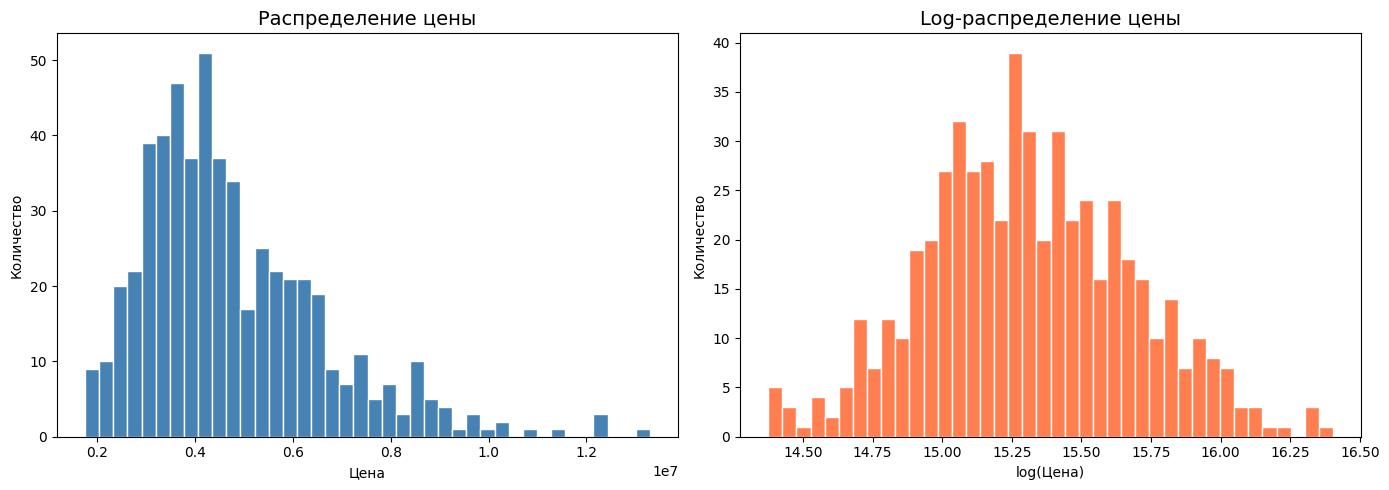

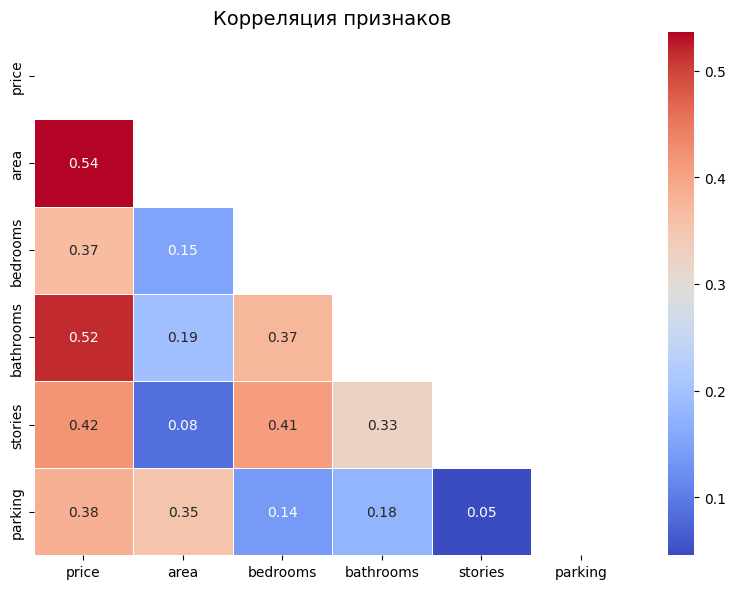

/tmp/ipykernel_552/3250990489.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_552/3250990489.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_552/3250990489.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_552/3250990489.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

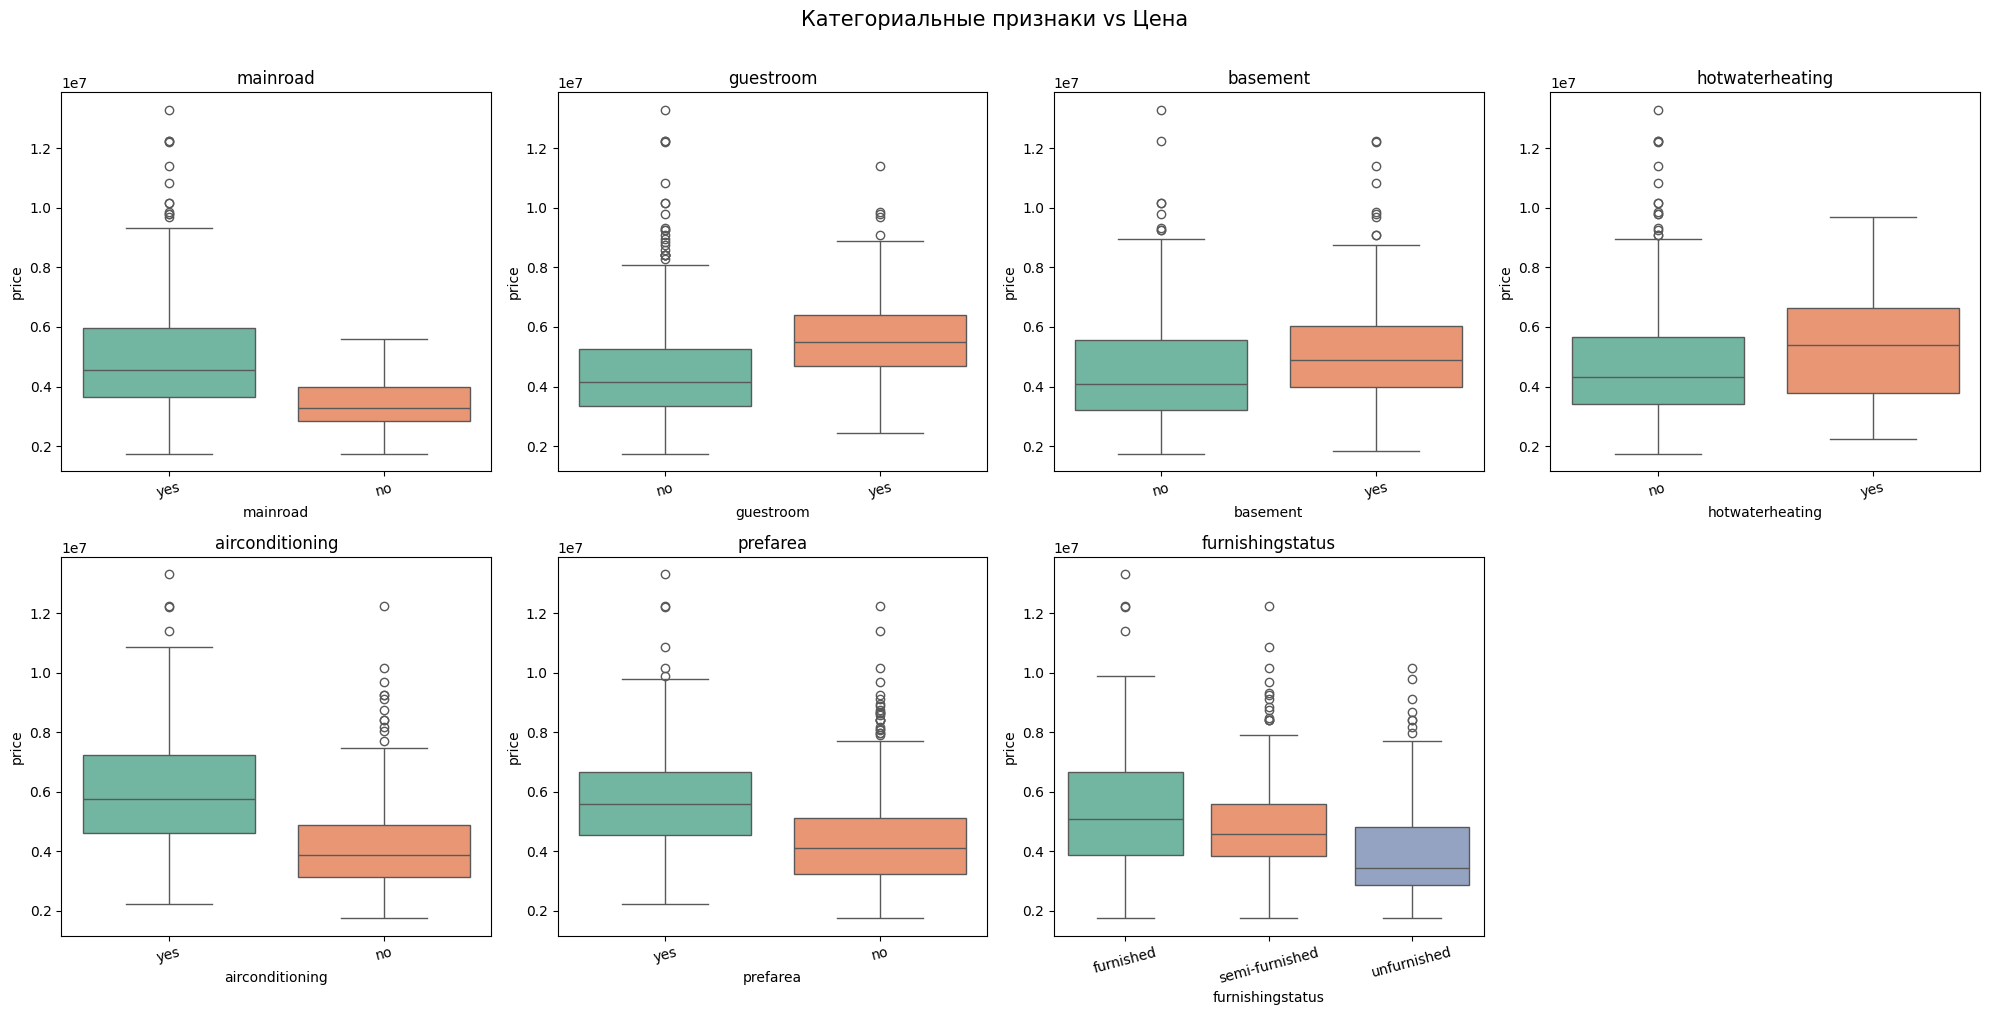

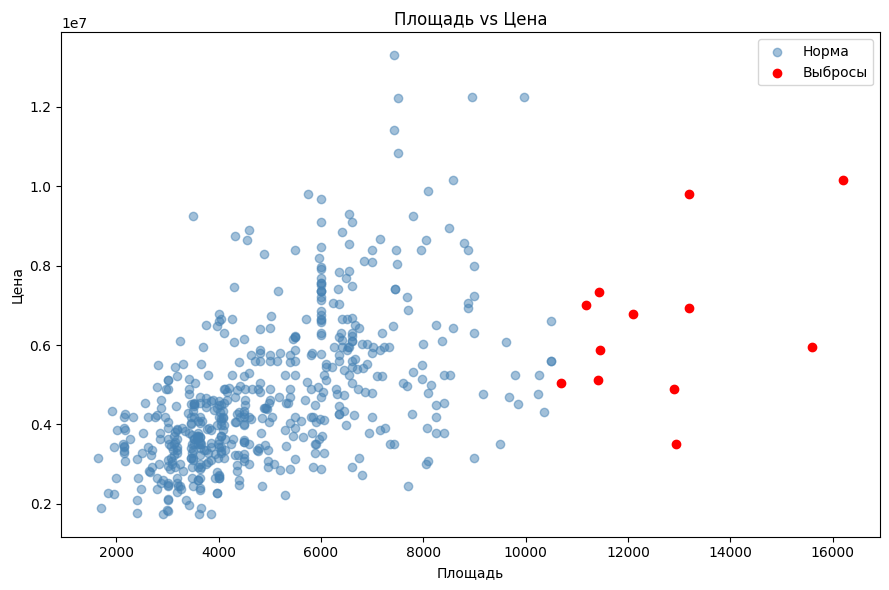

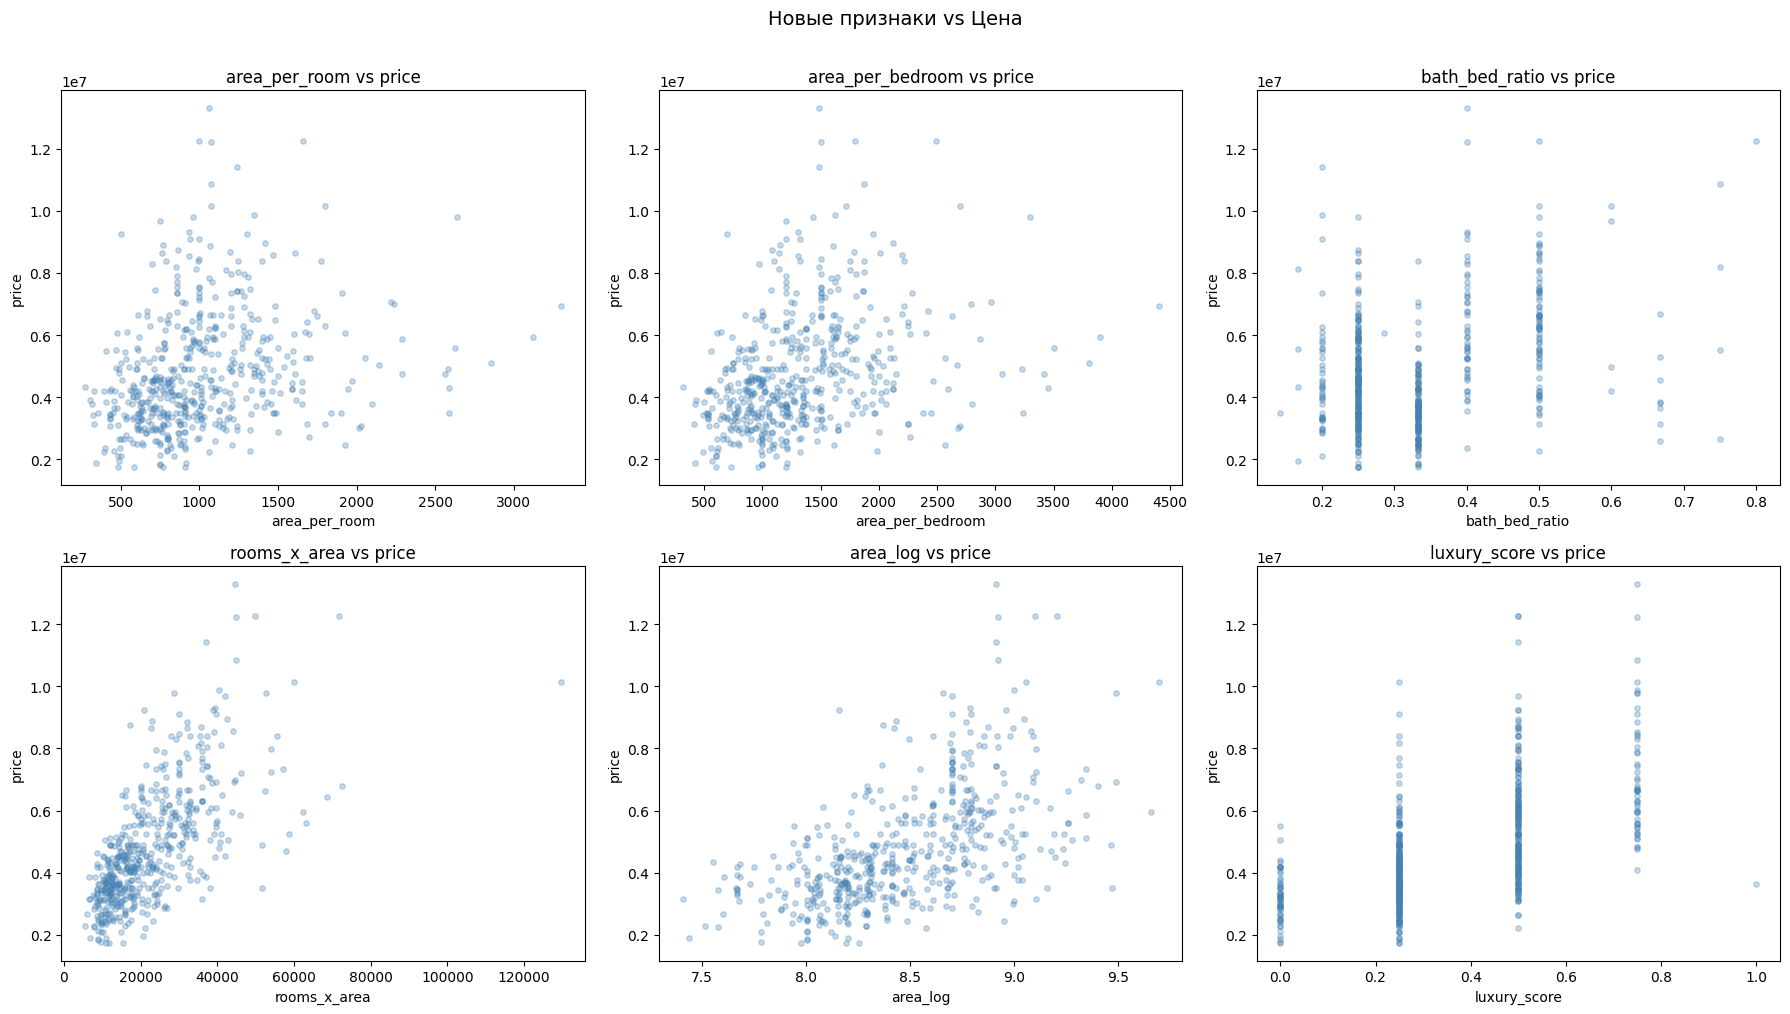


Отобранные признаки: ['area', 'bedrooms', 'bathrooms', 'stories', 'airconditioning', 'parking', 'total_rooms', 'has_luxury', 'luxury_score', 'stories_parking', 'rooms_x_area', 'area_log']


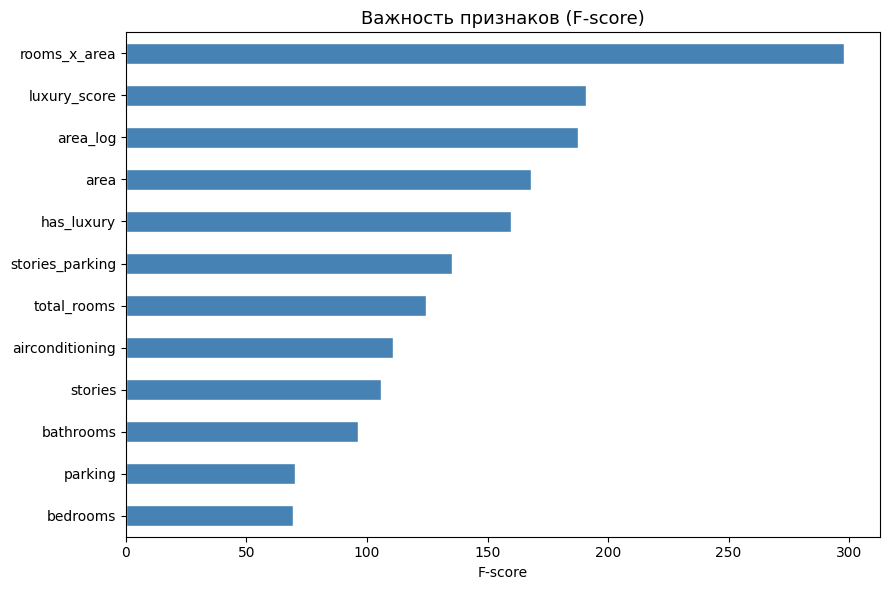


Гиперпараметрический поиск...
ЛУЧШИЙ! R²: 0.7051 | LR: 0.001 | Batch: 16 | Hidden: [64, 32] | Dropout: 0.1
ЛУЧШИЙ! R²: 0.7106 | LR: 0.0005 | Batch: 16 | Hidden: [64, 32] | Dropout: 0.2
ЛУЧШИЙ! R²: 0.7179 | LR: 0.0005 | Batch: 16 | Hidden: [128, 64] | Dropout: 0.3

ТОП-5:
1. R²: 0.7179 | LR: 0.0005 | Batch: 16 | Hidden: [128, 64] | Dropout: 0.3
2. R²: 0.7106 | LR: 0.0005 | Batch: 16 | Hidden: [64, 32] | Dropout: 0.2
3. R²: 0.7052 | LR: 0.0001 | Batch: 16 | Hidden: [128, 64, 32] | Dropout: 0.1
4. R²: 0.7052 | LR: 0.0005 | Batch: 32 | Hidden: [64, 32] | Dropout: 0.2
5. R²: 0.7051 | LR: 0.001 | Batch: 16 | Hidden: [64, 32] | Dropout: 0.1

ЛУЧШИЙ R²: 0.7179
КОНФИГ: LR=0.0005, Batch=16, Hidden=[128, 64], Dropout=0.3

ФИНАЛЬНОЕ ОБУЧЕНИЕ
Epoch 0: train=0.3292, val=0.3515
Epoch 50: train=0.1536, val=0.2006
Epoch 100: train=0.1493, val=0.1966
Epoch 150: train=0.1429, val=0.1963


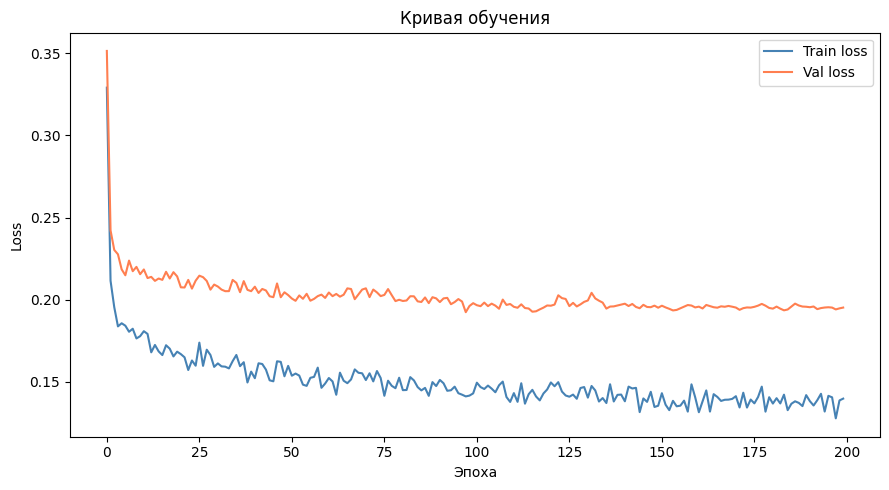


РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ
R²   : 0.6980
RMSE : 1139290
MAE  : 815794


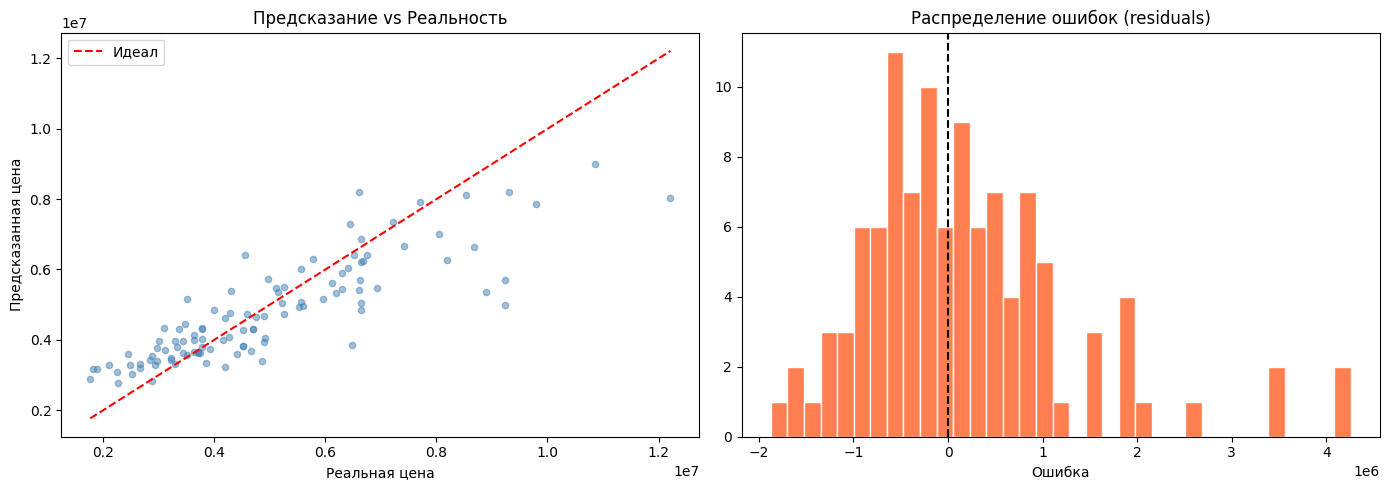


Модель сохранена → housing_model_v2.pth


In [13]:
# IMPORTS
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA

df = pd.read_csv("Housing.csv")

# EDA

df.info()
print(df.describe())

# VISUALIZATION 1:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение цены', fontsize=14)
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Количество')

axes[1].hist(np.log1p(df['price']), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Log-распределение цены', fontsize=14)
axes[1].set_xlabel('log(Цена)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

# VISUALIZATION 2:

plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Корреляция признаков', fontsize=14)
plt.tight_layout()
plt.show()

# VISUALIZATION 3:

cat_cols = df.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Категориальные признаки vs Цена', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# VISUALIZATION 4:

Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1
area_outliers = df[df['area'] > Q3 + 1.5 * IQR]
normal = df[df['area'] <= Q3 + 1.5 * IQR]

plt.figure(figsize=(9, 6))
plt.scatter(normal['area'], normal['price'], alpha=0.5, label='Норма', color='steelblue')
plt.scatter(area_outliers['area'], area_outliers['price'], color='red', label='Выбросы', zorder=5)
plt.xlabel('Площадь')
plt.ylabel('Цена')
plt.title('Площадь vs Цена')
plt.legend()
plt.tight_layout()
plt.show()

# CLEANING

binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df = df.drop_duplicates()

# FEATURE ENGINEERING

df['total_rooms']      = df['bedrooms'] + df['bathrooms']
df['area_per_room']    = df['area'] / (df['total_rooms'] + 1)
df['area_per_bedroom'] = df['area'] / (df['bedrooms'] + 1)
df['bath_bed_ratio']   = df['bathrooms'] / (df['bedrooms'] + 1)
df['has_luxury']       = df['airconditioning'] + df['hotwaterheating'] + df['prefarea']
df['luxury_score']     = (df['airconditioning'] + df['hotwaterheating'] +
                          df['prefarea'] + df['mainroad']) / 4
df['stories_parking']  = df['stories'] * df['parking']
df['rooms_x_area']     = df['total_rooms'] * df['area']
df['area_log']         = np.log1p(df['area'])
df['price_segment']    = pd.qcut(df['price'], q=4, labels=False)


df = df.drop(columns=['price_segment'])

# VISUALIZATION 5:

new_feats = ['area_per_room', 'area_per_bedroom', 'bath_bed_ratio',
             'rooms_x_area', 'area_log', 'luxury_score']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(new_feats):
    axes[i].scatter(df[feat], df['price'], alpha=0.3, color='steelblue', s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{feat} vs price')

plt.suptitle('Новые признаки vs Цена', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# OUTLIER REMOVAL

low  = df['price'].quantile(0.005)
high = df['price'].quantile(0.995)
df   = df[(df['price'] >= low) & (df['price'] <= high)]

# SPLIT

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FEATURE SELECTION

from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=12)
selector.fit(X_train, y_train)
selected_features = X.columns[selector.get_support()]
print(f"\nОтобранные признаки: {list(selected_features)}")

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# VISUALIZATION 6:

scores = selector.scores_[selector.get_support()]
feat_importance = pd.Series(scores, index=selected_features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Важность признаков (F-score)', fontsize=13)
plt.xlabel('F-score')
plt.tight_layout()
plt.show()

# SCALING

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

X_test_scaled  = scaler_X.transform(X_test)
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

y_test_actual = y_test.values.reshape(-1, 1)

# TENSORS

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test_scaled,  dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)


# HYPERPARAMETER SEARCH

learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes    = [16, 32]
hidden_layers  = [[64, 32], [128, 64], [128, 64, 32], [64, 32, 16]]
dropouts       = [0.1, 0.2, 0.3]

best_r2     = -float('inf')
best_config = None
results     = []

print("\nГиперпараметрический поиск...")
print("=" * 60)

for lr in learning_rates:
    for batch_size in batch_sizes:
        for hidden in hidden_layers:
            for dropout in dropouts:
                layers   = []
                prev_dim = X_train_scaled.shape[1]
                for h in hidden:
                    layers += [nn.Linear(prev_dim, h), nn.ReLU(), nn.Dropout(dropout)]
                    prev_dim = h
                layers.append(nn.Linear(prev_dim, 1))
                model = nn.Sequential(*layers)

                loader    = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
                criterion = nn.SmoothL1Loss()

                for epoch in range(120):
                    model.train()
                    for xb, yb in loader:
                        optimizer.zero_grad()
                        loss = criterion(model(xb), yb)
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()

                model.eval()
                with torch.no_grad():
                    preds = scaler_y.inverse_transform(model(X_test_tensor).numpy())
                    r2    = r2_score(y_test_actual, preds)

                results.append((r2, lr, batch_size, hidden, dropout))

                if r2 > best_r2:
                    best_r2     = r2
                    best_config = (lr, batch_size, hidden, dropout)
                    print(f"ЛУЧШИЙ! R²: {r2:.4f} | LR: {lr} | Batch: {batch_size} | Hidden: {hidden} | Dropout: {dropout}")

results.sort(reverse=True)
print("\n" + "=" * 60)
print("ТОП-5:")
for i, (r2, lr, bs, h, d) in enumerate(results[:5]):
    print(f"{i+1}. R²: {r2:.4f} | LR: {lr} | Batch: {bs} | Hidden: {h} | Dropout: {d}")

print(f"\nЛУЧШИЙ R²: {best_r2:.4f}")
print(f"КОНФИГ: LR={best_config[0]}, Batch={best_config[1]}, Hidden={best_config[2]}, Dropout={best_config[3]}")


best_lr, best_batch, best_hidden, best_dropout = best_config

layers   = []
prev_dim = X_train_scaled.shape[1]
for h in best_hidden:
    layers += [nn.Linear(prev_dim, h), nn.ReLU(), nn.Dropout(best_dropout)]
    prev_dim = h
layers.append(nn.Linear(prev_dim, 1))
final_model = nn.Sequential(*layers)

final_loader = DataLoader(train_dataset, batch_size=best_batch, shuffle=True)
optimizer    = torch.optim.Adam(final_model.parameters(), lr=best_lr, weight_decay=1e-4)
scheduler    = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
criterion    = nn.SmoothL1Loss()

train_losses = []
val_losses   = []

print("\n" + "=" * 60)
print("ФИНАЛЬНОЕ ОБУЧЕНИЕ")
print("=" * 60)

for epoch in range(200):
    final_model.train()
    total = 0
    for xb, yb in final_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()

    train_losses.append(total / len(final_loader))

    final_model.eval()
    with torch.no_grad():
        val_loss = criterion(final_model(X_test_tensor), y_test_tensor).item()
    val_losses.append(val_loss)

    scheduler.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")

# VISUALIZATION 7: Loss curve

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train loss', color='steelblue')
plt.plot(val_losses,   label='Val loss',   color='coral')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Кривая обучения')
plt.legend()
plt.tight_layout()
plt.show()


final_model.eval()
with torch.no_grad():
    final_preds = scaler_y.inverse_transform(final_model(X_test_tensor).numpy())

final_r2   = r2_score(y_test_actual, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test_actual, final_preds))
final_mae  = mean_absolute_error(y_test_actual, final_preds)

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ")
print("=" * 60)
print(f"R²   : {final_r2:.4f}")
print(f"RMSE : {final_rmse:.0f}")
print(f"MAE  : {final_mae:.0f}")


# VISUALIZATION 8:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_actual, final_preds, alpha=0.5, color='steelblue', s=20)
mn = min(y_test_actual.min(), final_preds.min())
mx = max(y_test_actual.max(), final_preds.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Идеал')
axes[0].set_xlabel('Реальная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('Предсказание vs Реальность')
axes[0].legend()

residuals = y_test_actual.flatten() - final_preds.flatten()
axes[1].hist(residuals, bins=35, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Распределение ошибок (residuals)')
axes[1].set_xlabel('Ошибка')

plt.tight_layout()
plt.show()

# SAVE

torch.save(final_model.state_dict(), "housing_model_v2.pth")
print("\nМодель сохранена → housing_model_v2.pth")